# Linear vs robust IMF final-residual distributions

**Objective.** Compare the Monte Carlo distributions of

\[
R_K(Y)=Y-\sum_{k=1}^K \widehat S_k(Y)
\]

for the repository's linear local-mean IMF and smooth robust-location IMF algorithms.
Both algorithms receive the same contaminated observation in every repetition.

The requested noise model is fixed throughout:

- Gaussian scale: \(\sigma=0.1\);
- contamination probability: \(p=0.2\);
- signed exponential contamination magnitude with scale \(3\sigma=0.3\).

We study both the literal final residual \(R_K(Y)\) and the clean-centered perturbation

\[
\Delta R_K=R_K(Y)-R_K(X),
\]

which isolates stochastic propagation from the deterministic high-frequency portion of the clean signal that remains after the last stage.

In [1]:
from pathlib import Path
from statistics import NormalDist
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from numpy.lib.stride_tricks import sliding_window_view

SEED = 20260811
N = 512
N_REPETITIONS = 400
BATCH_SIZE = 16

SIGMA = 0.1
CONTAMINATION_PROB = 0.2
CONTAMINATION_SCALE = 3.0 * SIGMA
H = 2.0 * SIGMA

BANDWIDTH_FACTOR = np.sqrt(2.0)
MIN_WINDOW_SIZE = 31
BOUNDARY = "wrap"
ROBUST_MAX_ITER = 60
ROBUST_TOL = 1e-6

def find_project_root(start):
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "experiments").is_dir():
            return candidate
    raise RuntimeError("Could not locate the project root")


PROJECT_ROOT = find_project_root(Path.cwd())
OUTPUT_DIR = PROJECT_ROOT / "output/jupyter-notebook/residual-distribution-comparison"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

config = {
    "seed": SEED,
    "n": N,
    "n_repetitions": N_REPETITIONS,
    "batch_size": BATCH_SIZE,
    "sigma": SIGMA,
    "contamination_probability": CONTAMINATION_PROB,
    "contamination_scale": CONTAMINATION_SCALE,
    "robust_H": H,
    "bandwidth_factor": BANDWIDTH_FACTOR,
    "minimum_window_size": MIN_WINDOW_SIZE,
    "boundary": BOUNDARY,
    "robust_max_iter": ROBUST_MAX_ITER,
    "robust_tolerance": ROBUST_TOL,
}

pd.Series(config, name="value").to_frame()

,value
seed,20260811
n,512
n_repetitions,400
batch_size,16
sigma,0.1
contamination_probability,0.2
contamination_scale,0.3
robust_H,0.2
bandwidth_factor,1.414214
minimum_window_size,31


## Experimental plan

1. Reuse the repository's generated clean signal, squared-triangular kernel, bandwidth schedule, and signed-contamination convention.
2. Run a small end-to-end reconstruction check.
3. Run paired Monte Carlo simulations for the linear and robust algorithms.
4. Compare pooled residual values, fixed-location laws, residual energy/RMSE, maxima, and conditional behavior at contaminated versus uncontaminated indices.
5. Check the linear residual variance against the exact finite-sample circulant-operator calculation.

Pooled time-coordinate summaries are descriptive because coordinates within one residual are correlated. Fixed-location samples across Monte Carlo repetitions are independent.

In [2]:
def odd_ceiling(value):
    size = int(np.ceil(value))
    if size % 2 == 0:
        size += 1
    return max(1, size)


def nearest_odd(value):
    rounded = int(np.round(value))
    if rounded % 2 == 1:
        return max(1, rounded)
    lower = max(1, rounded - 1)
    upper = rounded + 1
    return lower if abs(value - lower) <= abs(upper - value) else upper


def make_window_schedule(n, factor=np.sqrt(2.0), min_window_size=31):
    if n <= 0:
        raise ValueError("n must be positive")
    if factor <= 1:
        raise ValueError("factor must be larger than 1")

    first = odd_ceiling(n / 2)
    if first > n:
        first = n if n % 2 == 1 else n - 1

    min_size = nearest_odd(min_window_size)
    if min_size > first:
        return [first]

    sizes = [first]
    current = first
    while current > min_size:
        candidate = nearest_odd(current / factor)
        candidate = min(candidate, current - 2)
        if candidate % 2 == 0:
            candidate -= 1
        if candidate < min_size:
            candidate = min_size
        sizes.append(candidate)
        current = candidate
    return sizes


TARGET_SIGNAL_STD = 0.38545431761087123


def gen_signal(t, seed=2026, target_std=TARGET_SIGNAL_STD):
    t = np.asarray(t, dtype=float)
    rng = np.random.default_rng(seed)
    u = (t - t.min()) / np.ptp(t)

    def center_and_scale(values, scale):
        values = np.asarray(values, dtype=float) - np.mean(values)
        values_std = np.std(values)
        return values if values_std == 0 else scale * values / values_std

    baseline = np.zeros_like(u)
    for harmonic in range(1, 6):
        amplitude = rng.normal(scale=1.0 / harmonic)
        phase = rng.uniform(0.0, 2.0 * np.pi)
        baseline += amplitude * np.sin(2.0 * np.pi * harmonic * u + phase)
    baseline = center_and_scale(baseline, scale=0.36)

    amplitude_envelope = 0.75 + 0.35 * np.sin(
        2.0 * np.pi * (1.3 * u + 0.08) + rng.uniform(0.0, 2.0 * np.pi)
    )
    chirp_phase = 2.0 * np.pi * (
        2.2 * u + 5.8 * u**2
        + 0.35 * np.sin(2.0 * np.pi * u + rng.uniform(0.0, 2.0 * np.pi))
    )
    chirp = center_and_scale(amplitude_envelope * np.sin(chirp_phase), scale=0.22)

    transients = np.zeros_like(u)
    for center, width, height in zip(
        rng.uniform(0.08, 0.92, size=8),
        rng.uniform(0.008, 0.04, size=8),
        rng.normal(0.0, 1.0, size=8),
    ):
        transients += height * np.exp(-0.5 * ((u - center) / width) ** 2)
    transients = center_and_scale(transients, scale=0.30)

    texture_raw = rng.normal(size=len(u))
    texture_radius = max(3, nearest_odd(0.02 * len(u)) // 2)
    offsets = np.arange(-texture_radius, texture_radius + 1)
    texture_kernel = np.exp(-0.5 * (offsets / max(1.0, texture_radius / 2.5)) ** 2)
    texture_kernel /= texture_kernel.sum()
    texture = np.convolve(texture_raw, texture_kernel, mode="same")
    texture = center_and_scale(texture, scale=0.08)

    components = {
        "baseline": baseline,
        "chirp": chirp,
        "transients": transients,
        "texture": texture,
    }
    signal = sum(components.values())
    rescale = target_std / signal.std()
    components = {name: values * rescale for name, values in components.items()}
    return sum(components.values()), components


def generate_observation_ensemble(signal, n_repetitions, rng):
    shape = (n_repetitions, len(signal))
    gaussian = rng.normal(0.0, SIGMA, size=shape)
    mask = rng.random(shape) < CONTAMINATION_PROB
    magnitudes = rng.exponential(CONTAMINATION_SCALE, size=shape)
    signs = rng.choice(np.array([-1.0, 1.0]), size=shape)
    contamination = mask * magnitudes * signs
    observation = signal[None, :] + gaussian + contamination
    return observation, {
        "gaussian": gaussian,
        "mask": mask,
        "contamination": contamination,
        "noise": gaussian + contamination,
    }


t = np.linspace(0.0, 1.0, N)
clean_signal, signal_components = gen_signal(t)
window_sizes = make_window_schedule(N, BANDWIDTH_FACTOR, MIN_WINDOW_SIZE)

schedule = pd.DataFrame({
    "stage": np.arange(1, len(window_sizes) + 1),
    "window_size": window_sizes,
    "radius": np.asarray(window_sizes) // 2,
})

assert np.isclose(clean_signal.std(), TARGET_SIGNAL_STD)
assert window_sizes == [257, 181, 127, 89, 63, 45, 31]
schedule

,stage,window_size,radius
0,1,257,128
1,2,181,90
2,3,127,63
3,4,89,44
4,5,63,31
5,6,45,22
6,7,31,15


In [3]:
SQRT_2 = np.sqrt(2.0)
SQRT_2_OVER_PI = np.sqrt(2.0 / np.pi)


def epanechnikov_weights(window_size):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")
    radius = window_size // 2
    if radius == 0:
        return np.array([1.0])
    offsets = np.arange(-radius, radius + 1)
    u = offsets / radius
    weights = 0.75 * np.maximum(0.0, 1.0 - np.abs(u)) ** 2
    return weights / weights.sum()


def erf_approx(values):
    values = np.asarray(values, dtype=float)
    sign = np.sign(values)
    ax = np.abs(values)
    p = 0.3275911
    a1, a2, a3, a4, a5 = (
        0.254829592,
        -0.284496736,
        1.421413741,
        -1.453152027,
        1.061405429,
    )
    z = 1.0 / (1.0 + p * ax)
    poly = (((((a5 * z + a4) * z + a3) * z + a2) * z + a1) * z)
    return sign * (1.0 - poly * np.exp(-(ax**2)))


def robust_score(residual, H):
    return erf_approx(np.asarray(residual, dtype=float) / (SQRT_2 * H))


def local_linear_filter_batch(signals, window_size):
    signals = np.atleast_2d(np.asarray(signals, dtype=float))
    radius = window_size // 2
    weights = epanechnikov_weights(window_size)
    padded = np.pad(signals, ((0, 0), (radius, radius)), mode=BOUNDARY)
    windows = sliding_window_view(padded, window_size, axis=1)
    return windows @ weights


def local_robust_filter_batch(signals, window_size, H):
    signals = np.atleast_2d(np.asarray(signals, dtype=float))
    radius = window_size // 2
    weights = epanechnikov_weights(window_size)[None, None, :]
    padded = np.pad(signals, ((0, 0), (radius, radius)), mode=BOUNDARY)
    windows = sliding_window_view(padded, window_size, axis=1)

    estimates = np.median(windows, axis=2)
    lower = windows.min(axis=2)
    upper = windows.max(axis=2)
    active = np.ones(len(signals), dtype=bool)
    iteration_counts = np.zeros(len(signals), dtype=int)
    step = 0.95 * H / SQRT_2_OVER_PI

    for iteration in range(1, ROBUST_MAX_ITER + 1):
        active_indices = np.flatnonzero(active)
        if len(active_indices) == 0:
            break

        current = estimates[active_indices]
        score = np.sum(
            weights * robust_score(windows[active_indices] - current[:, :, None], H),
            axis=2,
        )
        updated = np.clip(
            current + step * score,
            lower[active_indices],
            upper[active_indices],
        )
        max_delta = np.max(np.abs(updated - current), axis=1)
        threshold = ROBUST_TOL * (1.0 + np.max(np.abs(updated), axis=1))
        estimates[active_indices] = updated

        finished = max_delta <= threshold
        finished_indices = active_indices[finished]
        iteration_counts[finished_indices] = iteration
        active[finished_indices] = False

    iteration_counts[active] = ROBUST_MAX_ITER
    return estimates, iteration_counts


def linear_imf_batch(signals):
    residual = np.atleast_2d(np.asarray(signals, dtype=float)).copy()
    imfs = []
    for window_size in window_sizes:
        component = local_linear_filter_batch(residual, window_size)
        imfs.append(component)
        residual = residual - component
    return np.stack(imfs, axis=1), residual


def robust_imf_batch(signals):
    residual = np.atleast_2d(np.asarray(signals, dtype=float)).copy()
    imfs = []
    stage_iterations = []
    for window_size in window_sizes:
        component, iterations = local_robust_filter_batch(residual, window_size, H)
        imfs.append(component)
        stage_iterations.append(iterations)
        residual = residual - component
    return np.stack(imfs, axis=1), residual, np.stack(stage_iterations, axis=1)

## Minimal end-to-end baseline

The reconstruction identity is algebraic, but checking it here catches shape, padding, and batching errors before the Monte Carlo run.

In [4]:
baseline_rng = np.random.default_rng(SEED)
baseline_observations, baseline_noise = generate_observation_ensemble(
    clean_signal, 2, baseline_rng
)

baseline_linear_imfs, baseline_linear_residual = linear_imf_batch(baseline_observations)
baseline_robust_imfs, baseline_robust_residual, baseline_iterations = robust_imf_batch(
    baseline_observations
)

linear_reconstruction_error = np.max(np.abs(
    baseline_observations
    - baseline_linear_imfs.sum(axis=1)
    - baseline_linear_residual
))
robust_reconstruction_error = np.max(np.abs(
    baseline_observations
    - baseline_robust_imfs.sum(axis=1)
    - baseline_robust_residual
))

baseline_checks = pd.DataFrame([
    {"method": "linear", "max_reconstruction_error": linear_reconstruction_error},
    {"method": "robust", "max_reconstruction_error": robust_reconstruction_error},
])

assert baseline_checks["max_reconstruction_error"].max() < 1e-12
assert np.all(np.isfinite(baseline_robust_residual))
baseline_checks

,method,max_reconstruction_error
0,linear,2.428613e-16
1,robust,2.393918e-16


## Paired Monte Carlo experiment

Noise is generated once and reused by both algorithms. Simulations are processed in batches only to control memory use; all retained outputs have shape `n_repetitions × n`.

In [5]:
rng = np.random.default_rng(SEED)
observations, noise_info = generate_observation_ensemble(clean_signal, N_REPETITIONS, rng)

clean_linear_imfs, clean_linear_residual_2d = linear_imf_batch(clean_signal)
clean_robust_imfs, clean_robust_residual_2d, clean_robust_iterations = robust_imf_batch(
    clean_signal
)
clean_linear_residual = clean_linear_residual_2d[0]
clean_robust_residual = clean_robust_residual_2d[0]

linear_residual = np.empty_like(observations)
robust_residual = np.empty_like(observations)
robust_iteration_counts = np.empty((N_REPETITIONS, len(window_sizes)), dtype=int)

started = time.perf_counter()
for batch_start in range(0, N_REPETITIONS, BATCH_SIZE):
    batch_stop = min(batch_start + BATCH_SIZE, N_REPETITIONS)
    batch = observations[batch_start:batch_stop]

    _, linear_batch_residual = linear_imf_batch(batch)
    _, robust_batch_residual, batch_iterations = robust_imf_batch(batch)

    linear_residual[batch_start:batch_stop] = linear_batch_residual
    robust_residual[batch_start:batch_stop] = robust_batch_residual
    robust_iteration_counts[batch_start:batch_stop] = batch_iterations

    if batch_stop % 80 == 0 or batch_stop == N_REPETITIONS:
        print(f"completed {batch_stop:>3}/{N_REPETITIONS} repetitions")

elapsed_seconds = time.perf_counter() - started

linear_delta = linear_residual - clean_linear_residual[None, :]
robust_delta = robust_residual - clean_robust_residual[None, :]

realized_contamination_fraction = noise_info["mask"].mean()
print(f"elapsed: {elapsed_seconds:.2f} s")
print(f"realized contamination fraction: {realized_contamination_fraction:.4f}")
print(f"robust fits at iteration cap: {(robust_iteration_counts == ROBUST_MAX_ITER).mean():.4%}")

completed  80/400 repetitions


completed 160/400 repetitions


completed 240/400 repetitions


completed 320/400 repetitions


completed 400/400 repetitions
elapsed: 22.02 s
realized contamination fraction: 0.2016
robust fits at iteration cap: 0.0000%


In [6]:
def reconstruction_error_from_residual(observation, residual, algorithm):
    # Re-run only a small deterministic subset with components retained.
    if algorithm == "linear":
        imfs, checked_residual = linear_imf_batch(observation)
    else:
        imfs, checked_residual, _ = robust_imf_batch(observation)
    error = np.max(np.abs(observation - imfs.sum(axis=1) - checked_residual))
    residual_match = np.max(np.abs(residual - checked_residual))
    return float(error), float(residual_match)


linear_check = reconstruction_error_from_residual(
    observations[:3], linear_residual[:3], "linear"
)
robust_check = reconstruction_error_from_residual(
    observations[:3], robust_residual[:3], "robust"
)

validation = pd.DataFrame([
    {
        "method": "linear",
        "max_reconstruction_error": linear_check[0],
        "stored_residual_match_error": linear_check[1],
    },
    {
        "method": "robust",
        "max_reconstruction_error": robust_check[0],
        "stored_residual_match_error": robust_check[1],
    },
])

assert validation[["max_reconstruction_error", "stored_residual_match_error"]].to_numpy().max() < 1e-12
assert abs(realized_contamination_fraction - CONTAMINATION_PROB) < 0.01
assert np.all(np.isfinite(linear_delta)) and np.all(np.isfinite(robust_delta))
validation

,method,max_reconstruction_error,stored_residual_match_error
0,linear,4.440892e-16,0.0
1,robust,2.220446e-16,0.0


## Distribution summaries

The standardized tail fractions use each displayed sample's own mean and standard deviation. KS distances are reported as descriptive distances; no pooled-coordinate p-values are used because time coordinates are dependent.

In [7]:
def normal_cdf(values):
    return 0.5 * (1.0 + erf_approx(np.asarray(values) / SQRT_2))


def ks_distance_to_standard_normal(standardized_values):
    values = np.sort(np.asarray(standardized_values, dtype=float).ravel())
    n_values = len(values)
    cdf = normal_cdf(values)
    upper = np.arange(1, n_values + 1) / n_values
    lower = np.arange(0, n_values) / n_values
    return float(max(np.max(upper - cdf), np.max(cdf - lower)))


def distribution_statistics(values):
    values = np.asarray(values, dtype=float).ravel()
    mean = values.mean()
    sd = values.std()
    z = (values - mean) / sd
    quantiles = np.quantile(values, [0.005, 0.025, 0.50, 0.975, 0.995])
    return {
        "mean": mean,
        "sd": sd,
        "skewness": np.mean(z**3),
        "excess_kurtosis": np.mean(z**4) - 3.0,
        "q_0.005": quantiles[0],
        "q_0.025": quantiles[1],
        "median": quantiles[2],
        "q_0.975": quantiles[3],
        "q_0.995": quantiles[4],
        "standardized_tail_prob_abs_gt_2.5": np.mean(np.abs(z) > 2.5),
        "standardized_tail_prob_abs_gt_3": np.mean(np.abs(z) > 3.0),
        "ks_distance_to_normal": ks_distance_to_standard_normal(z),
    }


distribution_rows = []
for method, raw, delta in [
    ("linear", linear_residual, linear_delta),
    ("robust", robust_residual, robust_delta),
]:
    for quantity, values in [("literal final residual", raw), ("clean-centered perturbation", delta)]:
        distribution_rows.append({
            "method": method,
            "quantity": quantity,
            **distribution_statistics(values),
        })

distribution_summary = pd.DataFrame(distribution_rows)
distribution_summary

,method,quantity,mean,sd,skewness,excess_kurtosis,q_0.005,q_0.025,median,q_0.975,q_0.995,standardized_tail_prob_abs_gt_2.5,standardized_tail_prob_abs_gt_3,ks_distance_to_normal
0,linear,literal final residual,9.351244e-21,0.197871,-0.136817,13.531986,-0.797829,-0.388519,-0.000163,0.390673,0.801670,0.032788,0.022388,0.100730
1,linear,clean-centered perturbation,4.079311e-20,0.194932,-0.143534,14.430103,-0.797197,-0.382685,0.000116,0.389137,0.799349,0.033433,0.023052,0.107080
2,robust,literal final residual,-3.802234e-05,0.204562,-0.172012,18.502733,-0.871208,-0.395650,-0.000230,0.399210,0.876006,0.033521,0.024058,0.125735
3,robust,clean-centered perturbation,-1.476448e-04,0.201898,-0.179446,19.530933,-0.868552,-0.391926,-0.000090,0.397018,0.872617,0.034121,0.024546,0.132594


In [8]:
fixed_indices = [N // 4, N // 2, 3 * N // 4]
fixed_point_rows = []
for method, delta in [("linear", linear_delta), ("robust", robust_delta)]:
    for index in fixed_indices:
        fixed_point_rows.append({
            "method": method,
            "index": index,
            "t": t[index],
            **distribution_statistics(delta[:, index]),
        })

fixed_point_summary = pd.DataFrame(fixed_point_rows)
fixed_point_summary

,method,index,t,mean,sd,skewness,excess_kurtosis,q_0.005,q_0.025,median,q_0.975,q_0.995,standardized_tail_prob_abs_gt_2.5,standardized_tail_prob_abs_gt_3,ks_distance_to_normal
0,linear,128,0.250489,-0.001010,0.200009,-0.694284,13.802939,-0.620045,-0.379084,0.002504,0.423574,0.665706,0.0375,0.0200,0.122057
1,linear,256,0.500978,0.020966,0.201450,0.493825,14.500824,-0.713843,-0.352986,0.012041,0.415858,0.768241,0.0300,0.0225,0.138100
2,linear,384,0.751468,-0.003042,0.187975,-0.600072,9.545158,-0.891460,-0.322741,-0.001864,0.307587,0.768535,0.0350,0.0275,0.132324
3,robust,128,0.250489,0.000764,0.207862,-0.918145,18.732250,-0.671914,-0.392692,-0.002673,0.452941,0.716564,0.0375,0.0225,0.154607
4,robust,256,0.500978,0.019953,0.209761,0.601474,18.899376,-0.787465,-0.354744,0.008784,0.413576,0.886315,0.0300,0.0225,0.162907
5,robust,384,0.751468,-0.006464,0.192360,-0.833666,13.140724,-0.999096,-0.336866,0.001143,0.322074,0.807748,0.0375,0.0250,0.154538


## Exact linear variance check

With periodic boundaries, the linear residual operator is circulant. Applying it to a unit impulse gives one row of the operator. For the signed contamination model,

\[
\operatorname{Var}(\varepsilon_t)
=\sigma^2+2p\,b^2,
\]

where \(b\) is the exponential scale. Therefore the pointwise residual-perturbation variance is exactly the noise variance times the squared norm of the impulse response.

In [9]:
impulse = np.zeros(N)
impulse[0] = 1.0
_, impulse_response_2d = linear_imf_batch(impulse)
impulse_response = impulse_response_2d[0]

theoretical_input_noise_variance = (
    SIGMA**2 + 2.0 * CONTAMINATION_PROB * CONTAMINATION_SCALE**2
)
theoretical_linear_variance = (
    theoretical_input_noise_variance * np.sum(impulse_response**2)
)
empirical_linear_pointwise_variance = np.mean(np.var(linear_delta, axis=0, ddof=0))
empirical_linear_second_moment = np.mean(linear_delta**2)

linear_theory_check = pd.DataFrame([{
    "input_noise_variance": theoretical_input_noise_variance,
    "operator_row_squared_norm": np.sum(impulse_response**2),
    "theoretical_pointwise_variance": theoretical_linear_variance,
    "empirical_mean_pointwise_variance": empirical_linear_pointwise_variance,
    "empirical_pooled_second_moment": empirical_linear_second_moment,
    "empirical_to_theory_variance_ratio": empirical_linear_second_moment / theoretical_linear_variance,
}])

assert abs(linear_theory_check.loc[0, "empirical_to_theory_variance_ratio"] - 1.0) < 0.10
linear_theory_check

,input_noise_variance,operator_row_squared_norm,theoretical_pointwise_variance,empirical_mean_pointwise_variance,empirical_pooled_second_moment,empirical_to_theory_variance_ratio
0,0.046,0.815849,0.037529,0.037895,0.037998,1.012507


## Replicate-level energy, maxima, and contamination retention

A robust component estimator can deliberately leave isolated outliers in the final residual. Heavier robust-residual tails therefore need not mean that the estimated IMFs are worse; it may mean that contamination was prevented from entering the extracted components.

In [10]:
replicate_frames = []
for method, raw, delta in [
    ("linear", linear_residual, linear_delta),
    ("robust", robust_residual, robust_delta),
]:
    replicate_frames.append(pd.DataFrame({
        "method": method,
        "repetition": np.arange(N_REPETITIONS),
        "literal_residual_rmse": np.sqrt(np.mean(raw**2, axis=1)),
        "perturbation_rmse": np.sqrt(np.mean(delta**2, axis=1)),
        "perturbation_energy": np.mean(delta**2, axis=1),
        "perturbation_max_abs": np.max(np.abs(delta), axis=1),
    }))
replicate_metrics = pd.concat(replicate_frames, ignore_index=True)

metric_rows = []
for method, frame in replicate_metrics.groupby("method", sort=False):
    for metric in [
        "literal_residual_rmse",
        "perturbation_rmse",
        "perturbation_energy",
        "perturbation_max_abs",
    ]:
        values = frame[metric].to_numpy()
        metric_rows.append({
            "method": method,
            "metric": metric,
            "mean": values.mean(),
            "sd": values.std(),
            "q_0.05": np.quantile(values, 0.05),
            "median": np.median(values),
            "q_0.95": np.quantile(values, 0.95),
        })
replicate_metric_summary = pd.DataFrame(metric_rows)
replicate_metric_summary

,method,metric,mean,sd,q_0.05,median,q_0.95
0,linear,literal_residual_rmse,0.196948,0.019090,0.169799,0.195534,0.230121
1,linear,perturbation_rmse,0.193960,0.019445,0.166726,0.192834,0.227257
2,linear,perturbation_energy,0.037998,0.007794,0.027798,0.037185,0.051646
3,linear,perturbation_max_abs,1.387069,0.354169,0.936945,1.318381,2.101337
4,robust,literal_residual_rmse,0.203491,0.020907,0.173845,0.201830,0.239819
5,robust,perturbation_rmse,0.200778,0.021243,0.170769,0.199434,0.237413
6,robust,perturbation_energy,0.040763,0.008822,0.029162,0.039774,0.056365
7,robust,perturbation_max_abs,1.550456,0.407075,1.042199,1.471247,2.379279


In [11]:
paired_wide = replicate_metrics.pivot(
    index="repetition", columns="method"
)
paired_rows = []
for metric in [
    "literal_residual_rmse",
    "perturbation_rmse",
    "perturbation_energy",
    "perturbation_max_abs",
]:
    linear_values = paired_wide[metric]["linear"].to_numpy()
    robust_values = paired_wide[metric]["robust"].to_numpy()
    difference = robust_values - linear_values
    paired_rows.append({
        "metric": metric,
        "linear_mean": linear_values.mean(),
        "robust_mean": robust_values.mean(),
        "robust_to_linear_mean_ratio": robust_values.mean() / linear_values.mean(),
        "mean_paired_difference_robust_minus_linear": difference.mean(),
        "q_0.025_paired_difference": np.quantile(difference, 0.025),
        "q_0.975_paired_difference": np.quantile(difference, 0.975),
        "fraction_robust_greater_than_linear": np.mean(difference > 0.0),
    })

paired_method_comparison = pd.DataFrame(paired_rows)
paired_method_comparison

,metric,linear_mean,robust_mean,robust_to_linear_mean_ratio,mean_paired_difference_robust_minus_linear,q_0.025_paired_difference,q_0.975_paired_difference,fraction_robust_greater_than_linear
0,literal_residual_rmse,0.196948,0.203491,1.033221,0.006543,0.003069,0.011005,1.0000
1,perturbation_rmse,0.193960,0.200778,1.035152,0.006818,0.003318,0.011185,1.0000
2,perturbation_energy,0.037998,0.040763,1.072754,0.002765,0.001105,0.005258,1.0000
3,perturbation_max_abs,1.387069,1.550456,1.117793,0.163387,0.066564,0.310571,0.9975


In [12]:
contamination_rows = []
mask = noise_info["mask"]
contamination = noise_info["contamination"]

for method, delta in [("linear", linear_delta), ("robust", robust_delta)]:
    for location_type, selected in [("contaminated", mask), ("not contaminated", ~mask)]:
        absolute_values = np.abs(delta[selected])
        contamination_rows.append({
            "method": method,
            "location_type": location_type,
            "count": len(absolute_values),
            "mean_abs_perturbation": absolute_values.mean(),
            "median_abs_perturbation": np.median(absolute_values),
            "q_0.90_abs_perturbation": np.quantile(absolute_values, 0.90),
            "q_0.99_abs_perturbation": np.quantile(absolute_values, 0.99),
        })

    contaminated_values = contamination[mask]
    contaminated_residual = delta[mask]
    slope = np.dot(contaminated_values, contaminated_residual) / np.dot(
        contaminated_values, contaminated_values
    )
    correlation = np.corrcoef(contaminated_values, contaminated_residual)[0, 1]
    contamination_rows.append({
        "method": method,
        "location_type": "contamination retention",
        "count": mask.sum(),
        "mean_abs_perturbation": np.nan,
        "median_abs_perturbation": np.nan,
        "q_0.90_abs_perturbation": np.nan,
        "q_0.99_abs_perturbation": np.nan,
        "contamination_to_residual_slope": slope,
        "contamination_residual_correlation": correlation,
    })

contamination_summary = pd.DataFrame(contamination_rows)
contamination_summary

,method,location_type,count,mean_abs_perturbation,median_abs_perturbation,q_0.90_abs_perturbation,q_0.99_abs_perturbation,contamination_to_residual_slope,contamination_residual_correlation
0,linear,contaminated,41282,0.277957,0.200789,0.620055,1.225172,NaN,NaN
1,linear,not contaminated,163518,0.081402,0.068319,0.167541,0.270105,NaN,NaN
2,linear,contamination retention,41282,NaN,NaN,NaN,NaN,0.866641,0.963203
3,robust,contaminated,41282,0.288079,0.196066,0.663163,1.356970,NaN,NaN
4,robust,not contaminated,163518,0.073768,0.061943,0.152356,0.243382,NaN,NaN
5,robust,contamination retention,41282,NaN,NaN,NaN,NaN,0.933108,0.969434


## Visual comparison

The first figure shows one paired realization. The distribution figures then separate literal residuals, clean-centered perturbations, fixed-location behavior, and replicate-level functionals.

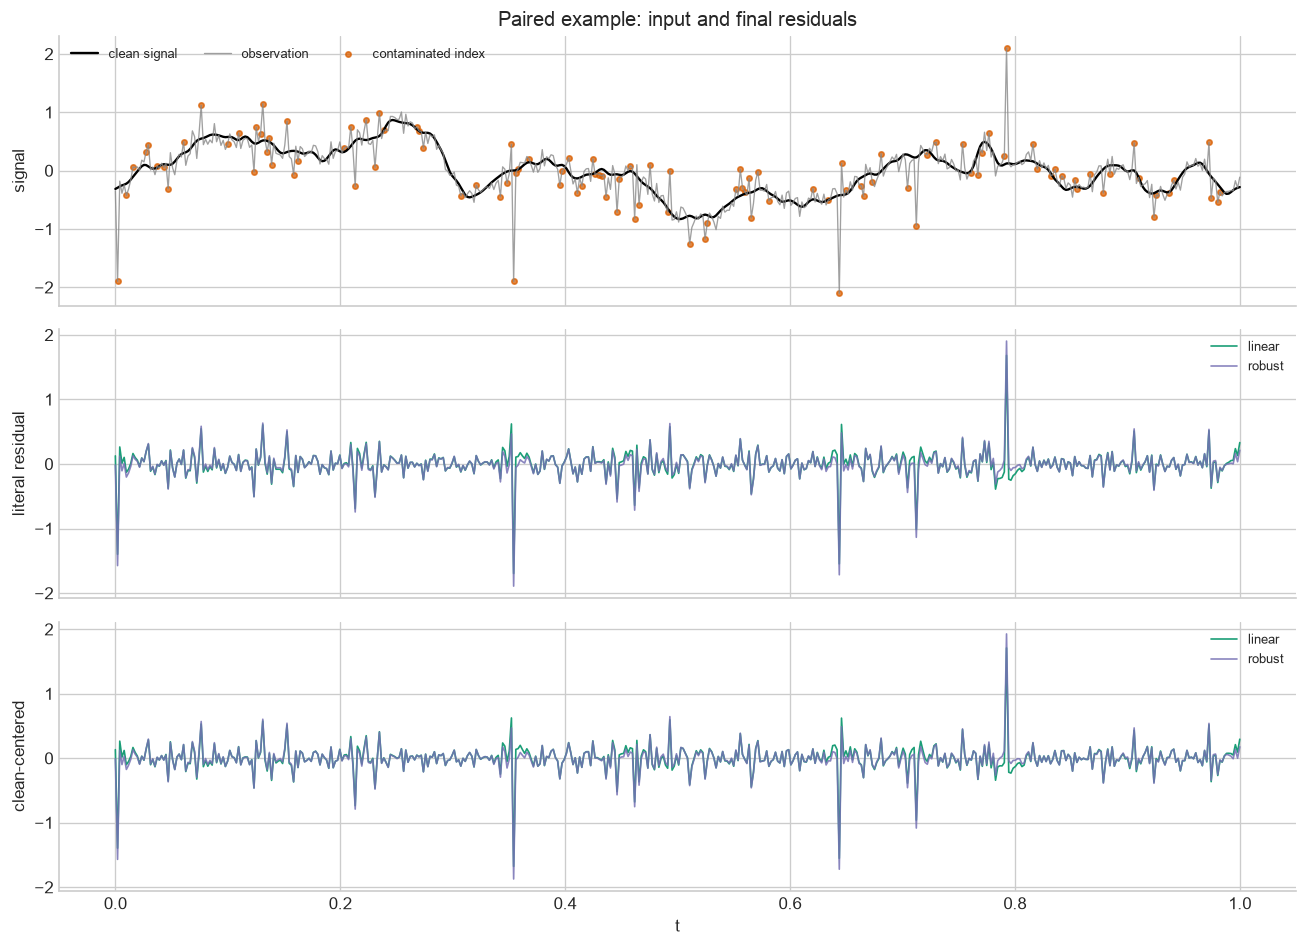

In [13]:
example_index = 0
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(t, clean_signal, color="black", lw=1.4, label="clean signal")
axes[0].plot(t, observations[example_index], color="#888888", lw=0.8, alpha=0.8, label="observation")
contaminated_example = noise_info["mask"][example_index]
axes[0].scatter(
    t[contaminated_example], observations[example_index, contaminated_example],
    s=10, color="#d95f02", alpha=0.75, label="contaminated index",
)
axes[0].set_ylabel("signal")
axes[0].legend(ncol=3, fontsize=8)
axes[0].set_title("Paired example: input and final residuals")

axes[1].plot(t, linear_residual[example_index], color="#1b9e77", lw=1.0, label="linear")
axes[1].plot(t, robust_residual[example_index], color="#7570b3", lw=1.0, alpha=0.85, label="robust")
axes[1].set_ylabel("literal residual")
axes[1].legend(fontsize=8)

axes[2].plot(t, linear_delta[example_index], color="#1b9e77", lw=1.0, label="linear")
axes[2].plot(t, robust_delta[example_index], color="#7570b3", lw=1.0, alpha=0.85, label="robust")
axes[2].set_ylabel("clean-centered")
axes[2].set_xlabel("t")
axes[2].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "paired_example_residuals.png", bbox_inches="tight")
plt.show()

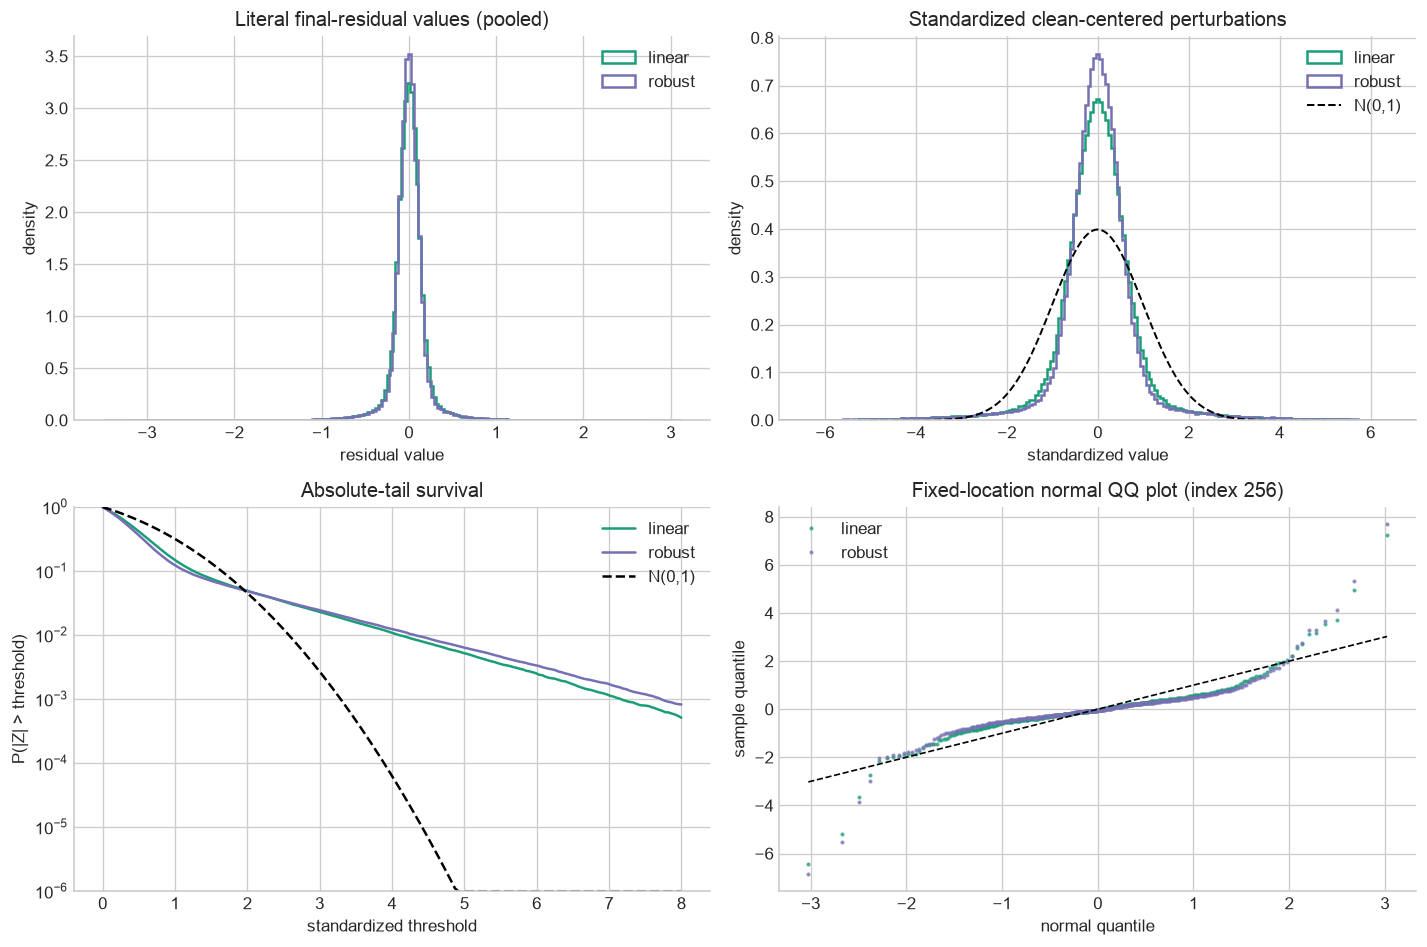

In [14]:
colors = {"linear": "#1b9e77", "robust": "#7570b3"}
normal_grid = np.linspace(-5.0, 5.0, 600)
normal_density = np.exp(-0.5 * normal_grid**2) / np.sqrt(2.0 * np.pi)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for method, raw in [("linear", linear_residual), ("robust", robust_residual)]:
    axes[0, 0].hist(
        raw.ravel(), bins=180, density=True, histtype="step", lw=1.5,
        color=colors[method], label=method,
    )
axes[0, 0].set_title("Literal final-residual values (pooled)")
axes[0, 0].set_xlabel("residual value")
axes[0, 0].set_ylabel("density")
axes[0, 0].legend()

standardized = {}
for method, delta in [("linear", linear_delta), ("robust", robust_delta)]:
    values = delta.ravel()
    z = (values - values.mean()) / values.std()
    standardized[method] = z
    axes[0, 1].hist(
        z, bins=np.linspace(-7, 7, 220), density=True, histtype="step",
        lw=1.5, color=colors[method], label=method,
    )
axes[0, 1].plot(normal_grid, normal_density, color="black", ls="--", lw=1.2, label="N(0,1)")
axes[0, 1].set_xlim(-7, 7)
axes[0, 1].set_title("Standardized clean-centered perturbations")
axes[0, 1].set_xlabel("standardized value")
axes[0, 1].set_ylabel("density")
axes[0, 1].legend()

thresholds = np.linspace(0.0, 8.0, 180)
for method, z in standardized.items():
    survival = np.array([np.mean(np.abs(z) > threshold) for threshold in thresholds])
    axes[1, 0].semilogy(thresholds, np.maximum(survival, 1e-6), color=colors[method], label=method)
gaussian_survival = 2.0 * (1.0 - normal_cdf(thresholds))
axes[1, 0].semilogy(thresholds, np.maximum(gaussian_survival, 1e-6), color="black", ls="--", label="N(0,1)")
axes[1, 0].set_ylim(1e-6, 1.0)
axes[1, 0].set_title("Absolute-tail survival")
axes[1, 0].set_xlabel("standardized threshold")
axes[1, 0].set_ylabel("P(|Z| > threshold)")
axes[1, 0].legend()

center = N // 2
probabilities = (np.arange(N_REPETITIONS) + 0.5) / N_REPETITIONS
theoretical_quantiles = np.array([NormalDist().inv_cdf(p) for p in probabilities])
for method, delta in [("linear", linear_delta), ("robust", robust_delta)]:
    sample = delta[:, center]
    sample_z = np.sort((sample - sample.mean()) / sample.std())
    axes[1, 1].plot(
        theoretical_quantiles, sample_z, marker=".", ms=3, lw=0,
        alpha=0.65, color=colors[method], label=method,
    )
diagonal = [theoretical_quantiles.min(), theoretical_quantiles.max()]
axes[1, 1].plot(diagonal, diagonal, color="black", ls="--", lw=1.0)
axes[1, 1].set_title(f"Fixed-location normal QQ plot (index {center})")
axes[1, 1].set_xlabel("normal quantile")
axes[1, 1].set_ylabel("sample quantile")
axes[1, 1].legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / "distribution_diagnostics.png", bbox_inches="tight")
plt.show()

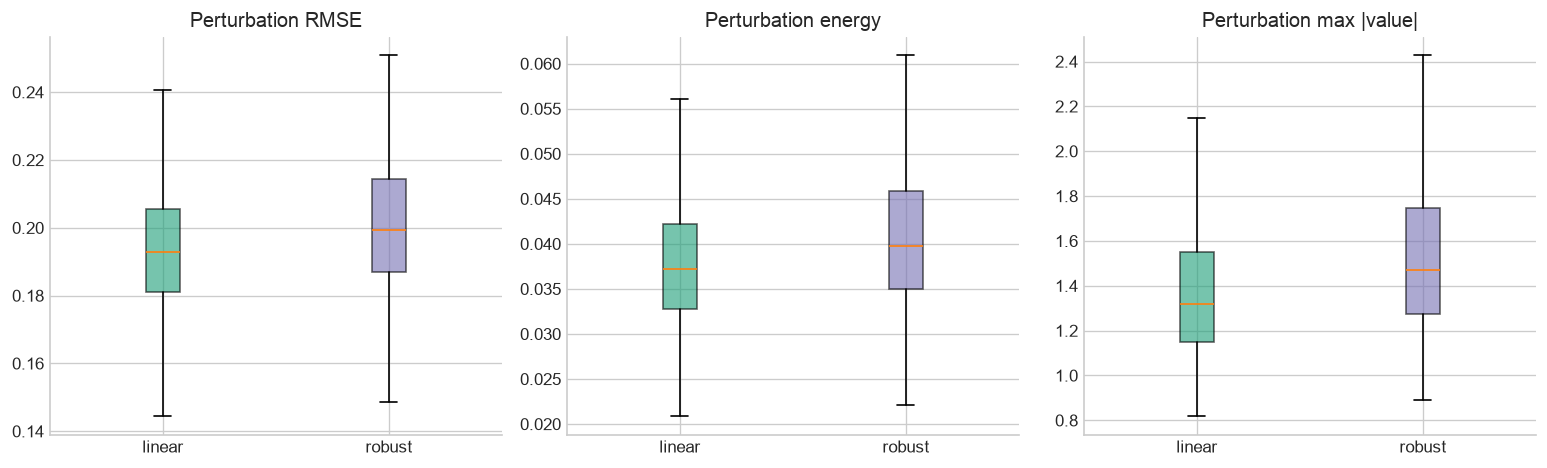

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metric_specs = [
    ("perturbation_rmse", "Perturbation RMSE"),
    ("perturbation_energy", "Perturbation energy"),
    ("perturbation_max_abs", "Perturbation max |value|"),
]
for axis, (metric, title) in zip(axes, metric_specs):
    values = [
        replicate_metrics.loc[replicate_metrics["method"] == method, metric]
        for method in ["linear", "robust"]
    ]
    box = axis.boxplot(values, tick_labels=["linear", "robust"], patch_artist=True, showfliers=False)
    for patch, method in zip(box["boxes"], ["linear", "robust"]):
        patch.set_facecolor(colors[method])
        patch.set_alpha(0.6)
    axis.set_title(title)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "replicate_metrics.png", bbox_inches="tight")
plt.show()

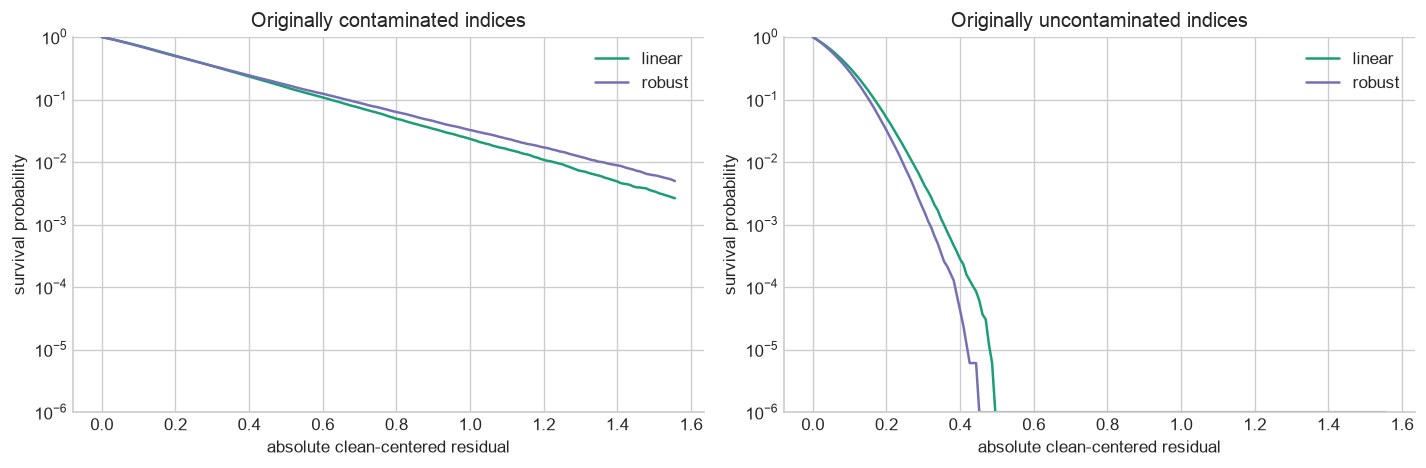

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
thresholds = np.linspace(0.0, np.quantile(np.abs(robust_delta), 0.999), 180)
for axis, selected, title in [
    (axes[0], mask, "Originally contaminated indices"),
    (axes[1], ~mask, "Originally uncontaminated indices"),
]:
    for method, delta in [("linear", linear_delta), ("robust", robust_delta)]:
        values = np.abs(delta[selected])
        survival = np.array([np.mean(values > threshold) for threshold in thresholds])
        axis.semilogy(
            thresholds, np.maximum(survival, 1e-6),
            color=colors[method], label=method,
        )
    axis.set_title(title)
    axis.set_xlabel("absolute clean-centered residual")
    axis.set_ylabel("survival probability")
    axis.set_ylim(1e-6, 1.0)
    axis.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "conditional_contamination_tails.png", bbox_inches="tight")
plt.show()

## Exported numerical artifacts

Summary tables, replicate-level metrics, and figures are saved next to this notebook so the comparisons can be reused without rerunning the robust Monte Carlo calculation.

In [17]:
pd.Series(config, name="value").rename_axis("parameter").to_csv(OUTPUT_DIR / "configuration.csv")
schedule.to_csv(OUTPUT_DIR / "window_schedule.csv", index=False)
distribution_summary.to_csv(OUTPUT_DIR / "distribution_summary.csv", index=False)
fixed_point_summary.to_csv(OUTPUT_DIR / "fixed_point_summary.csv", index=False)
linear_theory_check.to_csv(OUTPUT_DIR / "linear_theory_check.csv", index=False)
replicate_metrics.to_csv(OUTPUT_DIR / "replicate_metrics.csv", index=False)
replicate_metric_summary.to_csv(OUTPUT_DIR / "replicate_metric_summary.csv", index=False)
paired_method_comparison.to_csv(OUTPUT_DIR / "paired_method_comparison.csv", index=False)
contamination_summary.to_csv(OUTPUT_DIR / "contamination_summary.csv", index=False)

exported_files = sorted(
    str(path.relative_to(OUTPUT_DIR))
    for path in OUTPUT_DIR.rglob("*")
    if path.is_file()
)
exported_files

['configuration.csv',
 'contamination_summary.csv',
 'distribution_summary.csv',
 'figures/conditional_contamination_tails.png',
 'figures/distribution_diagnostics.png',
 'figures/paired_example_residuals.png',
 'figures/replicate_metrics.png',
 'fixed_point_summary.csv',
 'linear_theory_check.csv',
 'paired_method_comparison.csv',
 'replicate_metric_summary.csv',
 'replicate_metrics.csv',
 'window_schedule.csv']

In [18]:
summary_index = distribution_summary.set_index(["method", "quantity"])
metric_index = replicate_metric_summary.set_index(["method", "metric"])
contamination_index = contamination_summary.set_index(["method", "location_type"])

linear_kurtosis = summary_index.loc[("linear", "clean-centered perturbation"), "excess_kurtosis"]
robust_kurtosis = summary_index.loc[("robust", "clean-centered perturbation"), "excess_kurtosis"]
linear_tail = summary_index.loc[("linear", "clean-centered perturbation"), "standardized_tail_prob_abs_gt_3"]
robust_tail = summary_index.loc[("robust", "clean-centered perturbation"), "standardized_tail_prob_abs_gt_3"]
linear_rmse = metric_index.loc[("linear", "perturbation_rmse"), "mean"]
robust_rmse = metric_index.loc[("robust", "perturbation_rmse"), "mean"]
linear_max = metric_index.loc[("linear", "perturbation_max_abs"), "mean"]
robust_max = metric_index.loc[("robust", "perturbation_max_abs"), "mean"]
linear_retention = contamination_index.loc[("linear", "contamination retention"), "contamination_to_residual_slope"]
robust_retention = contamination_index.loc[("robust", "contamination retention"), "contamination_to_residual_slope"]
paired_index = paired_method_comparison.set_index("metric")
energy_ratio = paired_index.loc["perturbation_energy", "robust_to_linear_mean_ratio"]
max_ratio = paired_index.loc["perturbation_max_abs", "robust_to_linear_mean_ratio"]
linear_uncontaminated = contamination_index.loc[("linear", "not contaminated"), "mean_abs_perturbation"]
robust_uncontaminated = contamination_index.loc[("robust", "not contaminated"), "mean_abs_perturbation"]
uncontaminated_ratio = robust_uncontaminated / linear_uncontaminated

verdict = f'''
## Numerical findings

- The exact linear operator calculation is validated: empirical/theoretical pooled second-moment ratio = **{linear_theory_check.loc[0, 'empirical_to_theory_variance_ratio']:.3f}**.
- Clean-centered excess kurtosis is **{linear_kurtosis:.2f}** for the linear residual and **{robust_kurtosis:.2f}** for the robust residual.
- The standardized probability beyond three standard deviations is **{linear_tail:.4f}** versus **{robust_tail:.4f}**.
- Mean perturbation RMSE is **{linear_rmse:.4f}** versus **{robust_rmse:.4f}**; mean maximum absolute perturbation is **{linear_max:.4f}** versus **{robust_max:.4f}**.
- Relative to the linear method, the robust final residual has **{100.0 * (energy_ratio - 1.0):.1f}%** more mean perturbation energy and **{100.0 * (max_ratio - 1.0):.1f}%** larger mean maximum, but **{100.0 * (1.0 - uncontaminated_ratio):.1f}%** lower mean absolute perturbation at originally uncontaminated indices.
- At originally contaminated coordinates, the fitted slope from contamination amplitude to final residual is **{linear_retention:.3f}** for the linear method and **{robust_retention:.3f}** for the robust method.

The robust algorithm is expected to leave more isolated contamination in the final residual while protecting the extracted IMF components. Consequently, a heavier-tailed robust **final residual** is evidence of outlier isolation, not automatically evidence of inferior component estimation.
'''
display(Markdown(verdict))


## Numerical findings

- The exact linear operator calculation is validated: empirical/theoretical pooled second-moment ratio = **1.013**.
- Clean-centered excess kurtosis is **14.43** for the linear residual and **19.53** for the robust residual.
- The standardized probability beyond three standard deviations is **0.0231** versus **0.0245**.
- Mean perturbation RMSE is **0.1940** versus **0.2008**; mean maximum absolute perturbation is **1.3871** versus **1.5505**.
- Relative to the linear method, the robust final residual has **7.3%** more mean perturbation energy and **11.8%** larger mean maximum, but **9.4%** lower mean absolute perturbation at originally uncontaminated indices.
- At originally contaminated coordinates, the fitted slope from contamination amplitude to final residual is **0.867** for the linear method and **0.933** for the robust method.

The robust algorithm is expected to leave more isolated contamination in the final residual while protecting the extracted IMF components. Consequently, a heavier-tailed robust **final residual** is evidence of outlier isolation, not automatically evidence of inferior component estimation.


## Follow-up directions

- Repeat the experiment over a grid of \(H/\sigma\), contamination probability, and contamination scale.
- Compare the IMF component errors against clean-reference components; this tests whether robust outlier retention improves the extracted signal decomposition.
- Replace pooled-coordinate normality diagnostics with simultaneous Gaussian-process or bootstrap bands when formal inference over time is required.